In [7]:
import pandas as pd
import numpy as np
import time
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
print("Đang tải dữ liệu...")
# Thay đường dẫn thực tế của bạn
df = pd.read_parquet("../data/black_spot.parquet")

Đang tải dữ liệu...


In [8]:
# Giả định black_spot đã được lọc các điểm đứng im, chỉ lấy x, y
# Rút gọn dữ liệu nếu quá lớn để test nhanh (vd: lấy 20,000 dòng ngẫu nhiên)
if len(df) > 20000:
    df_sample = df.sample(20000, random_state=42).copy()
else:
    df_sample = df.copy()

print(f"Số lượng điểm GPS đem ra Benchmark: {len(df_sample)}")

Số lượng điểm GPS đem ra Benchmark: 20000


In [9]:
# ==========================================
# 2. CHUYỂN ĐỔI TỌA ĐỘ SANG MÉT (Kỹ thuật từ helpers.py của bạn)
# ==========================================
# Tối ưu: Chuyển độ sang mét để dùng metric 'euclidean' cho lẹ, thay vì 'haversine' nặng nề
REF_LAT_RAD = np.radians(10.78)
METERS_PER_DEG_LAT = 111_320     
METERS_PER_DEG_LON = 111_320 * np.cos(REF_LAT_RAD)  

coords_m = np.column_stack([
    df_sample['y'].values * METERS_PER_DEG_LAT,
    df_sample['x'].values * METERS_PER_DEG_LON
])

# ==========================================
# 3. KHỞI TẠO CÁC MODEL (Thiết lập tham số công bằng)
# ==========================================
# - DBSCAN: Khoảng cách tối đa 100m, cần 15 xe kẹt để thành 1 điểm đen
# - HDBSCAN: Cần tối thiểu 15 xe kẹt để tạo cụm
# - KMeans: Ép tìm 50 điểm đen (Do KMeans không tự đoán được số cụm)

models = {
    "K-Means (k=50)": KMeans(n_clusters=50, random_state=42),
    "DBSCAN (eps=100m)": DBSCAN(eps=100, min_samples=15, metric='euclidean', n_jobs=-1),
    "HDBSCAN (min_size=15)": hdbscan.HDBSCAN(min_cluster_size=15, metric='euclidean', core_dist_n_jobs=-1)
}

In [10]:


results = []
cluster_labels = {}

# ==========================================
# 4. VÒNG LẶP BENCHMARK
# ==========================================
print("\nBẮT ĐẦU BENCHMARK THUẬT TOÁN...")
print("-" * 50)

for name, model in models.items():
    print(f"Đang chạy {name}...")
    
    # Đo thời gian chạy
    start_time = time.time()
    labels = model.fit_predict(coords_m)
    run_time = time.time() - start_time
    
    cluster_labels[name] = labels
    
    # Tính toán thông số
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = (n_noise / len(labels)) * 100
    
    # Chỉ tính Silhouette & Davies-Bouldin trên các điểm không phải là Nhiễu
    valid_idx = labels != -1
    if n_clusters > 1 and sum(valid_idx) > 0:
        sil_score = silhouette_score(coords_m[valid_idx], labels[valid_idx])
        db_score = davies_bouldin_score(coords_m[valid_idx], labels[valid_idx])
    else:
        sil_score = -1
        db_score = -1
        
    results.append({
        "Algorithm": name,
        "Time (sec)": round(run_time, 3),
        "Clusters Found": n_clusters,
        "Noise Ratio (%)": round(noise_ratio, 2),
        "Silhouette (↑)": round(sil_score, 3),
        "Davies-Bouldin (↓)": round(db_score, 3)
    })



BẮT ĐẦU BENCHMARK THUẬT TOÁN...
--------------------------------------------------
Đang chạy K-Means (k=50)...
Đang chạy DBSCAN (eps=100m)...
Đang chạy HDBSCAN (min_size=15)...


In [11]:

# ==========================================
# 5. IN BẢNG BÁO CÁO TỔNG KẾT
# ==========================================
results_df = pd.DataFrame(results)
print("\nKẾT QUẢ BENCHMARK (ĐỊNH LƯỢNG):")
print(results_df.to_markdown(index=False))


KẾT QUẢ BENCHMARK (ĐỊNH LƯỢNG):
| Algorithm             |   Time (sec) |   Clusters Found |   Noise Ratio (%) |   Silhouette (↑) |   Davies-Bouldin (↓) |
|:----------------------|-------------:|-----------------:|------------------:|-----------------:|---------------------:|
| K-Means (k=50)        |        0.054 |               50 |              0    |            0.84  |                0.462 |
| DBSCAN (eps=100m)     |        0.384 |              105 |              8.94 |            0.856 |                0.163 |
| HDBSCAN (min_size=15) |        0.542 |              289 |             21.18 |            0.743 |                0.298 |



Đang vẽ biểu đồ so sánh Không gian (Định tính)...


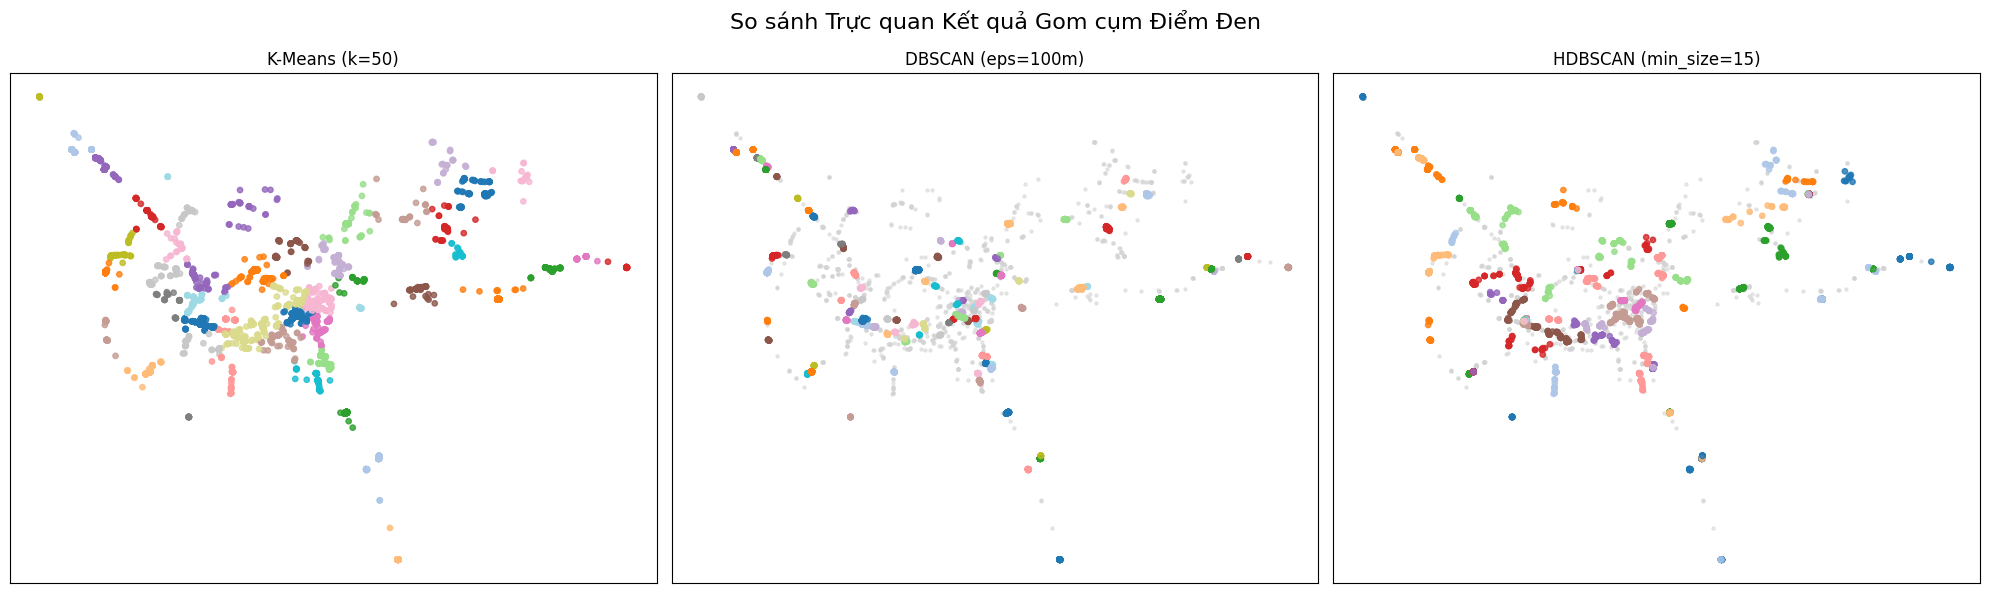

In [12]:


# ==========================================
# 6. VISUALIZATION: SO SÁNH BẰNG MẮT THƯỜNG (CỰC KỲ QUAN TRỌNG)
# ==========================================
print("\nĐang vẽ biểu đồ so sánh Không gian (Định tính)...")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('So sánh Trực quan Kết quả Gom cụm Điểm Đen', fontsize=16)

# Vẽ mẫu tối đa 10,000 điểm để matplotlib không bị treo
plot_mask = np.random.choice(len(df_sample), min(10000, len(df_sample)), replace=False)

for ax, name in zip(axes, models.keys()):
    lbls = cluster_labels[name][plot_mask]
    xs = df_sample['x'].values[plot_mask]
    ys = df_sample['y'].values[plot_mask]
    
    # Tách điểm nhiễu và điểm lõi
    core_mask = lbls != -1
    noise_mask = lbls == -1
    
    # Vẽ nhiễu màu xám nhạt
    ax.scatter(xs[noise_mask], ys[noise_mask], c='lightgrey', s=5, alpha=0.5, label='Noise')
    # Vẽ cụm có màu
    ax.scatter(xs[core_mask], ys[core_mask], c=lbls[core_mask], cmap='tab20', s=15, alpha=0.8)
    
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()